In [5]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [42]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [43]:
import seaborn as sns

# Approach if I needed to read CSV Files on a Website
### Unfortunately the file is a PDF and the tables aren't easily understood in python
### Much easier to copy the data onto a google sheets and download it as a CSV file

## Webscraping 

In [8]:
import requests
from bs4 import BeautifulSoup
import re

In [9]:
url = "https://www.aboutamazon.com/news/workplace/our-workforce-data"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

In [10]:
pdf_urls = []

In [11]:
# use requests and beautifulsoup to load the webpage and look for pdf links
for link in soup.find_all("a", href=True):
    if link["href"].lower().endswith(".pdf"):
        pdf_urls.append(link["href"])

In [12]:
pdf_urls

['https://assets.aboutamazon.com/89/0f/be7269b44b25b166030d7b2bfe27/2024-eeo1-amazon-report.pdf',
 'https://assets.aboutamazon.com/64/79/d3746ef14fd99cc6be94532c9db5/2023-eeo1-amazon-report.pdf',
 'https://assets.aboutamazon.com/9a/b0/8adc6b044b899fc826d4e35bda2d/2022-eeo1-amazon.pdf',
 'https://assets.aboutamazon.com/ff/dc/30bf8e3d41c7b250651f337a29c7/2021-amazon-consolidated-eeo-1-report-2p.pdf',
 'https://assets.aboutamazon.com/01/fb/29cebd144ec59269fe8ffda1ea07/amazon-2020-consolidated-type-2-eeo-1-report-r2.pdf',
 'https://assets.aboutamazon.com/33/47/bd6013354513af502fee43d3362a/amazon-2019-consolidated-type-2-eeo-1-report-r2.pdf']

In [13]:
from urllib.parse import urljoin
pdf_urls = [urljoin(url, pdf) for pdf in pdf_urls]

In [14]:
pdf_urls

['https://assets.aboutamazon.com/89/0f/be7269b44b25b166030d7b2bfe27/2024-eeo1-amazon-report.pdf',
 'https://assets.aboutamazon.com/64/79/d3746ef14fd99cc6be94532c9db5/2023-eeo1-amazon-report.pdf',
 'https://assets.aboutamazon.com/9a/b0/8adc6b044b899fc826d4e35bda2d/2022-eeo1-amazon.pdf',
 'https://assets.aboutamazon.com/ff/dc/30bf8e3d41c7b250651f337a29c7/2021-amazon-consolidated-eeo-1-report-2p.pdf',
 'https://assets.aboutamazon.com/01/fb/29cebd144ec59269fe8ffda1ea07/amazon-2020-consolidated-type-2-eeo-1-report-r2.pdf',
 'https://assets.aboutamazon.com/33/47/bd6013354513af502fee43d3362a/amazon-2019-consolidated-type-2-eeo-1-report-r2.pdf']

## Download PDFs
### This is good in the future just not for this. Its easier to just drag and transfer the data

In [15]:
import os 
import requests 

In [16]:
os.makedirs("pdfs", exist_ok=True)

In [17]:
for pdf_url in pdf_urls:
    filename = pdf_url.split("/")[-1]
    pdf_path = f"pdfs/{filename}"

    print("Downloading:", pdf_url)
    r = requests.get(pdf_url)
    with open(pdf_path, "wb") as f:
        f.write(r.content)

Downloading: https://assets.aboutamazon.com/89/0f/be7269b44b25b166030d7b2bfe27/2024-eeo1-amazon-report.pdf
Downloading: https://assets.aboutamazon.com/64/79/d3746ef14fd99cc6be94532c9db5/2023-eeo1-amazon-report.pdf
Downloading: https://assets.aboutamazon.com/9a/b0/8adc6b044b899fc826d4e35bda2d/2022-eeo1-amazon.pdf
Downloading: https://assets.aboutamazon.com/ff/dc/30bf8e3d41c7b250651f337a29c7/2021-amazon-consolidated-eeo-1-report-2p.pdf
Downloading: https://assets.aboutamazon.com/01/fb/29cebd144ec59269fe8ffda1ea07/amazon-2020-consolidated-type-2-eeo-1-report-r2.pdf
Downloading: https://assets.aboutamazon.com/33/47/bd6013354513af502fee43d3362a/amazon-2019-consolidated-type-2-eeo-1-report-r2.pdf


## Extracting Data From Each PDF

In [6]:
!pip install pdfplumber
import pdfplumber       # this extracts necessary values

In [7]:
for pdf_url in pdf_urls:
    filename = pdf_url.split("/")[-1]
    pdf_path = f"pdfs/{filename}"

    with pdfplumber.open(pdf_path) as pdf:
        text = "".join(page.extract_text() or "" for page in pdf.pages)
        print(f"--- Extracted from {filename} ---")
        print(text)  # print preview        

NameError: name 'pdf_urls' is not defined

In [ ]:
for pdf_url in pdf_urls:
    filename = pdf_url.split("/")[-1]
    pdf_path = f"pdfs/{filename}"

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            tables = page.extract_tables()
            for table in tables:
                print(table)

In [21]:
pip install camelot

  Using cached Camelot-12.06.29.tar.gz (3.5 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached SQLAlchemy-0.7.10.tar.gz (3.5 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [26 lines of output]
  Traceback (most recent call last):
    File "C:\Users\pepec\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
      main()
      ~~~~^^
    File "C:\Users\pepec\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
      json_out["return_val"] = hook(**hook_input["kwargs"])
                               ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\pepec\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
      return hook(config_settings)
    File "C:\Users\pepec\AppData\Local\Temp\pip-build-env-08y9im4e\overlay\Lib\site-packages\setuptools\build_meta.py", line 331, in g

In [22]:
import camelot
tables = camelot.read_pdf("file.pdf", pages="all")
tables[0].to_csv("output.csv")

ModuleNotFoundError: No module named 'camelot'

# Accessing CSV File

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
# url = "https://github.com/AlvaDave/Amazon-EEO-1/blob/main/Raw%20Amazon%20Data%202019-2024.csv"
# You dont copy the link. You instead click raw on github in order to get the link.
# I will update the data in the future
# url = "https://raw.githubusercontent.com/AlvaDave/Amazon-EEO-1/refs/heads/main/Raw%20Amazon%20EEO%202019-2024.csv"
url = "https://raw.githubusercontent.com/AlvaDave/Amazon-EEO-1/refs/heads/main/Amazon%20Converted%20-%202015%2C%202016%2C%202019-2024-2024.csv"
df = pd.read_csv(url)
df.head()

,Year,Job Category,Hispanic or Latino,White,Black or African American,Asian,Native Hawaiian or other Pacific Islander,American Indian or Alaska Native,Two or More Races,Sex
0,2024,Executive/Senior Level Officials and Managers,149,1864,148,751,5,9,53,Male
1,2024,First/Mid-Level Officials and Managers,8222,28235,6769,10838,181,238,1691,Male
2,2024,Professionals,7675,41321,4688,49423,160,142,3092,Male
3,2024,Technicians,2806,5915,1704,1228,54,74,480,Male
4,2024,Sales Workers,12138,19247,9037,5578,209,444,1481,Male


# Cleaning the CSV File, Saving it

In [9]:
# There are no duplicates but just in case 
df = df.drop_duplicates()

In [10]:
# Create a Dummy column so that Male = 1
df['Male'] = (df['Sex'] == 'Male').astype(int)
df.head()

,Year,Job Category,Hispanic or Latino,White,Black or African American,Asian,Native Hawaiian or other Pacific Islander,American Indian or Alaska Native,Two or More Races,Sex,Male
0,2024,Executive/Senior Level Officials and Managers,149,1864,148,751,5,9,53,Male,1
1,2024,First/Mid-Level Officials and Managers,8222,28235,6769,10838,181,238,1691,Male,1
2,2024,Professionals,7675,41321,4688,49423,160,142,3092,Male,1
3,2024,Technicians,2806,5915,1704,1228,54,74,480,Male,1
4,2024,Sales Workers,12138,19247,9037,5578,209,444,1481,Male,1


In [11]:
# Create a Dummy for all the job categories 
job_dummies = pd.get_dummies(df['Job Category'],prefix='job')
# this part is important bc otherwise it will turn things into booleans and turn your int64 categories to float
job_dummies = job_dummies.astype(int)
df = pd.concat([df,job_dummies],axis = 1)
df.head()

,Year,Job Category,Hispanic or Latino,White,Black or African American,Asian,Native Hawaiian or other Pacific Islander,American Indian or Alaska Native,Two or More Races,Sex,...,job_Administrative Support Workers,job_Craft Workers,job_Executive/Senior Level Officials and Managers,job_First/Mid-Level Officials and Managers,job_Laborers and Helpers,job_Operatives,job_Professionals,job_Sales Workers,job_Service Workers,job_Technicians
0,2024,Executive/Senior Level Officials and Managers,149,1864,148,751,5,9,53,Male,...,0,0,1,0,0,0,0,0,0,0
1,2024,First/Mid-Level Officials and Managers,8222,28235,6769,10838,181,238,1691,Male,...,0,0,0,1,0,0,0,0,0,0
2,2024,Professionals,7675,41321,4688,49423,160,142,3092,Male,...,0,0,0,0,0,0,1,0,0,0
3,2024,Technicians,2806,5915,1704,1228,54,74,480,Male,...,0,0,0,0,0,0,0,0,0,1
4,2024,Sales Workers,12138,19247,9037,5578,209,444,1481,Male,...,0,0,0,0,0,0,0,1,0,0


In [12]:
# Checking columns with numbers to ensure they are integers
df.dtypes

Year                                                  int64
Job Category                                         object
Hispanic or Latino                                    int64
White                                                 int64
Black or African American                             int64
Asian                                                 int64
Native Hawaiian or other Pacific Islander             int64
American Indian or Alaska Native                      int64
Two or More Races                                     int64
Sex                                                  object
Male                                                  int64
job_Administrative Support Workers                    int64
job_Craft Workers                                     int64
job_Executive/Senior Level Officials and Managers     int64
job_First/Mid-Level Officials and Managers            int64
job_Laborers and Helpers                              int64
job_Operatives                          

In [13]:
# Clean up white spaces
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

In [14]:
df.to_csv("Amazon_EEO1_Cleaned.csv", index=False)

In [15]:
df.columns = df.columns.str.strip()           # remove leading/trailing spaces
df.columns = df.columns.str.replace(" ", "_") # optional: replace spaces with _

In [16]:
list(df.columns)

['Year',
 'Job_Category',
 'Hispanic_or_Latino',
 'White',
 'Black_or_African_American',
 'Asian',
 'Native_Hawaiian_or_other_Pacific_Islander',
 'American_Indian_or_Alaska_Native',
 'Two_or_More_Races',
 'Sex',
 'Male',
 'job_Administrative_Support_Workers',
 'job_Craft_Workers',
 'job_Executive/Senior_Level_Officials_and_Managers',
 'job_First/Mid-Level_Officials_and_Managers',
 'job_Laborers_and_Helpers',
 'job_Operatives',
 'job_Professionals',
 'job_Sales_Workers',
 'job_Service_Workers',
 'job_Technicians']

In [63]:
# Rename Columns
# Renaming columns
df.columns = [
    'year',
 'job_category',
 'hispanic',
 'white',
 'black',
 'asian',
 'pacific_islander',
 'native',
 'mixed',
 'sex',
 'male',
 'job_Administrative_Support_Workers',
 'job_Craft_Workers',
 'job_Executive/Senior_Level_Officials_and_Managers',
 'job_First/Mid-Level_Officials_and_Managers',
 'job_Laborers_and_Helpers',
 'job_Operatives',
 'job_Professionals',
 'job_Sales_Workers',
 'job_Service_Workers',
 'job_Technicians']
df.head()



,year,job_category,hispanic,white,black,asian,pacific_islander,native,mixed,sex,...,job_Administrative_Support_Workers,job_Craft_Workers,job_Executive/Senior_Level_Officials_and_Managers,job_First/Mid-Level_Officials_and_Managers,job_Laborers_and_Helpers,job_Operatives,job_Professionals,job_Sales_Workers,job_Service_Workers,job_Technicians
0,2024,Executive/Senior Level Officials and Managers,149,1864,148,751,5,9,53,Male,...,0,0,1,0,0,0,0,0,0,0
1,2024,First/Mid-Level Officials and Managers,8222,28235,6769,10838,181,238,1691,Male,...,0,0,0,1,0,0,0,0,0,0
2,2024,Professionals,7675,41321,4688,49423,160,142,3092,Male,...,0,0,0,0,0,0,1,0,0,0
3,2024,Technicians,2806,5915,1704,1228,54,74,480,Male,...,0,0,0,0,0,0,0,0,0,1
4,2024,Sales Workers,12138,19247,9037,5578,209,444,1481,Male,...,0,0,0,0,0,0,0,1,0,0


# Exploratory Analysis

In [64]:
# Start with a few summaries 
df.describe()

,year,hispanic,white,black,asian,pacific_islander,native,mixed,male,job_Administrative_Support_Workers,job_Craft_Workers,job_Executive/Senior_Level_Officials_and_Managers,job_First/Mid-Level_Officials_and_Managers,job_Laborers_and_Helpers,job_Operatives,job_Professionals,job_Sales_Workers,job_Service_Workers,job_Technicians
count,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.00000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
mean,2020.000000,8790.818750,12778.087500,9927.943750,5550.043750,212.700000,306.556250,1235.781250,0.50000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000
std,3.009419,23057.262918,21645.503243,27645.166034,10869.985462,511.785416,785.256708,2573.986981,0.50157,0.300942,0.300942,0.300942,0.300942,0.300942,0.300942,0.300942,0.300942,0.300942,0.300942
min,2015.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018.250000,121.000000,884.500000,142.750000,168.250000,5.000000,8.750000,53.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2020.500000,1452.500000,4194.500000,1075.000000,743.500000,41.500000,52.500000,328.500000,0.50000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2022.250000,5486.500000,15950.750000,4901.000000,3861.000000,159.250000,192.250000,1195.750000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2024.000000,118254.000000,116887.000000,131339.000000,49423.000000,2338.000000,4315.000000,13170.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [65]:
df.groupby(['year','job_Executive/Senior_Level_Officials_and_Managers'])['white'].sum().unstack()

job_Executive/Senior_Level_Officials_and_Managers,0,1
year,,
2015,59092,99
2016,83110,98
2019,196105,1563
2020,303848,1850
2021,371003,2059
2022,353637,2339
2023,320992,2407
2024,343691,2601


In [67]:
df.groupby(['year','job_Executive/Senior_Level_Officials_and_Managers'])['black'].sum().unstack()

job_Executive/Senior_Level_Officials_and_Managers,0,1
year,,
2015,20704,0
2016,37463,0
2019,137315,39
2020,237690,93
2021,292333,172
2022,278635,230
2023,269494,212
2024,313846,245


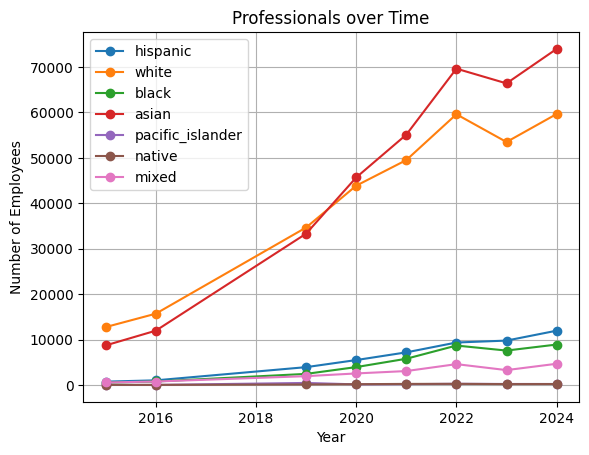

In [68]:
df_professionals = df[df['job_Professionals'] == 1]
race_sum = df_professionals.groupby('year')[[ 
    'hispanic',
    'white',
    'black',
    'asian',
    'pacific_islander',
    'native',
    'mixed']].sum()
race_sum.plot(kind='line', marker='o')
plt.title('Professionals over Time')
plt.ylabel('Number of Employees')
plt.xlabel('Year')
plt.grid(True)
plt.show()

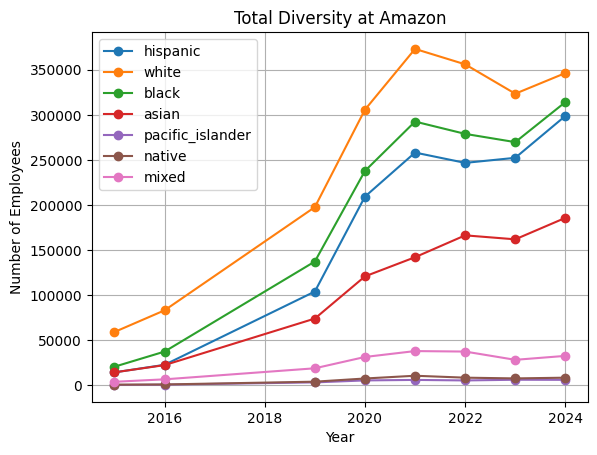

In [72]:
# Overall Diversity at Amazon 
df_total_diversity = df.groupby('year')[[
    'hispanic',
    'white',
    'black',
    'asian',
    'pacific_islander',
    'native',
    'mixed']].sum()
df_total_diversity.plot(kind='line', marker='o')
plt.title('Total Diversity at Amazon')
plt.ylabel('Number of Employees')
plt.xlabel('Year')
plt.grid(True)
plt.show()

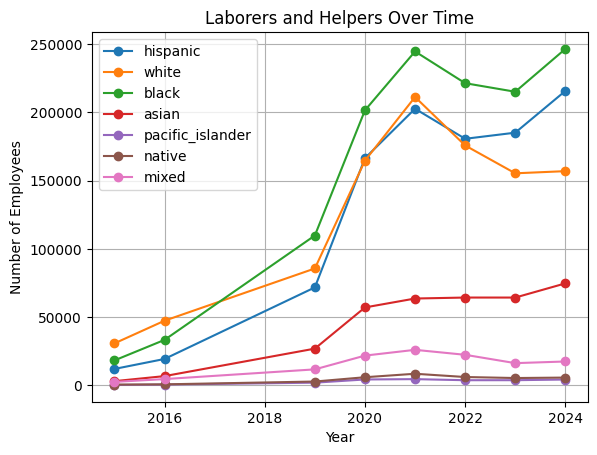

In [73]:
# Overall Diversity at Amazon = 
df_Laborers_and_Helpers = df[df['job_Laborers_and_Helpers'] == 1]
race_sum = df_Laborers_and_Helpers.groupby('year')[[
    'hispanic',
    'white',
    'black',
    'asian',
    'pacific_islander',
    'native',
    'mixed']].sum()
race_sum.plot(kind='line', marker='o')
plt.title('Laborers and Helpers Over Time')
plt.ylabel('Number of Employees')
plt.xlabel('Year')
plt.grid(True)
plt.show()

## Calculating growth rates from previous years

In [26]:
# Objective: 
# 1. Variables of interest
    # A. Professionals
    # B. Service Workers
# 2. Format a new data frame by...    Year  Race_Variable1 GrowthRateV1 Race_Variable2 GrowthRateV2
# 3. Create a chart representing the findings

In [74]:
list(df['job_category'].unique())

['Executive/Senior Level Officials and Managers',
 'First/Mid-Level Officials and Managers',
 'Professionals',
 'Technicians',
 'Sales Workers',
 'Administrative Support Workers',
 'Craft Workers',
 'Operatives',
 'Laborers and Helpers',
 'Service Workers']

In [75]:
df_total_gender = df.groupby(['year', 'sex']).sum().unstack() #The unstack puts the Male Female on top
df_total_gender

job_category  \
sex                                              Female   
year                                                      
2015  Executive/Senior Level Officials and ManagersF...   
2016  Executive/Senior Level Officials and ManagersF...   
2019  Executive/Senior Level Officials and ManagersF...   
2020  Executive/Senior Level Officials and ManagersF...   
2021  Executive/Senior Level Officials and ManagersF...   
2022  Executive/Senior Level Officials and ManagersF...   
2023  Executive/Senior Level Officials and ManagersF...   
2024  Executive/Senior Level Officials and ManagersF...   

                                                        hispanic          \
sex                                                Male   Female    Male   
year                                                                       
2015  Executive/Senior Level Officials and ManagersF...     6248    8178   
2016  Executive/Senior Level Officials and ManagersF...    10354   12440   
2019  Executive/Senior Level Officials and ManagersF...    51307   52765   
2020  Executive/Senior Level Officials and ManagersF...   104609  104689   
2021  Executive/Senior Level Officials and ManagersF...   130062  128078   
2022  Executive/Senior Level Officials and ManagersF...   125662  121050   
2023  Executive/Senior Level Officials and ManagersF...   128777  123550   
2024  Executive/Senior Level Officials and ManagersF...   153317  145445   

       white           black          asian          ... job_Operatives       \
sex   Female    Male  Female    Male Female    Male  ...         Female Male   
year                                                 ...                       
2015   21625   37566    9797   10907   4066   10380  ...              1    1   
2016   31955   51253   18661   18802   6778   15697  ...              1    1   
2019   80466  117202   74958   62396  26446   47647  ...              1    1   
2020  126088  179610  127650  110133  45770   75083  ...              1    1   
2021  153682  219380  154196  138309  54687   87421  ...              1    1   
2022  143668  212308  145923  132942  64291  102066  ...              1    1   
2023  129944  193455  138670  131036  63092   98843  ...              1    1   
2024  137714  208578  157976  156115  73350  112390  ...              1    1   

     job_Professionals      job_Sales_Workers      job_Service_Workers       \
sex             Female Male            Female Male              Female Male   
year                                                                          
2015                 1    1                 1    1                   1    1   
2016                 1    1                 1    1                   1    1   
2019                 1    1                 1    1                   1    1   
2020                 1    1                 1    1                   1    1   
2021                 1    1                 1    1                   1    1   
2022                 1    1                 1    1                   1    1   
2023                 1    1                 1    1                   1    1   
2024                 1    1                 1    1                   1    1   

     job_Technicians       
sex           Female Male  
year                       
2015               1    1  
2016               1    1  
2019               1    1  
2020               1    1  
2021               1    1  
2022               1    1  
2023               1    1  
2024               1    1  

[8 rows x 38 columns]

In [29]:
# Organizes df by Year and Job_Category by creating gender totals
df_totals = (
    df.groupby(['year','job_category'])
      .sum(numeric_only=True)
)
df_totals.head()

Hispanic_or_Latino  White  \
Year Job_Category                                                               
2015 Administrative Support Workers                                310   3810   
     Craft Workers                                                  38    363   
     Executive/Senior Level Officials and Managers                   1     99   
     First/Mid-Level Officials and Managers                        414   6492   
     Laborers and Helpers                                        12098  30824   

                                                    Black_or_African_American  \
Year Job_Category                                                               
2015 Administrative Support Workers                                       447   
     Craft Workers                                                         33   
     Executive/Senior Level Officials and Managers                          0   
     First/Mid-Level Officials and Managers                               433   
     Laborers and Helpers                                               18341   

                                                    Asian  \
Year Job_Category                                           
2015 Administrative Support Workers                   323   
     Craft Workers                                      6   
     Executive/Senior Level Officials and Managers      6   
     First/Mid-Level Officials and Managers          1850   
     Laborers and Helpers                            3156   

                                                    Native_Hawaiian_or_other_Pacific_Islander  \
Year Job_Category                                                                               
2015 Administrative Support Workers                                                        15   
     Craft Workers                                                                          5   
     Executive/Senior Level Officials and Managers                                          0   
     First/Mid-Level Officials and Managers                                                 9   
     Laborers and Helpers                                                                 394   

                                                    American_Indian_or_Alaska_Native  \
Year Job_Category                                                                      
2015 Administrative Support Workers                                               36   
     Craft Workers                                                                 2   
     Executive/Senior Level Officials and Managers                                 0   
     First/Mid-Level Officials and Managers                                       23   
     Laborers and Helpers                                                        634   

                                                    Two_or_More_Races  Male  \
Year Job_Category                                                             
2015 Administrative Support Workers                               195     1   
     Craft Workers                                                 22     1   
     Executive/Senior Level Officials and Managers                  1     1   
     First/Mid-Level Officials and Managers                       253     1   
     Laborers and Helpers                                        2612     1   

                                                    job_Administrative_Support_Workers  \
Year Job_Category                                                                        
2015 Administrative Support Workers                                                  2   
     Craft Workers                                                                   0   
     Executive/Senior Level Officials and Managers                                   0   
     First/Mid-Level Officials and Managers                                          0   
     Laborers and Helpers                                                            0   

      

In [30]:
# df.groupby(['Year', 'Sex']).sum()

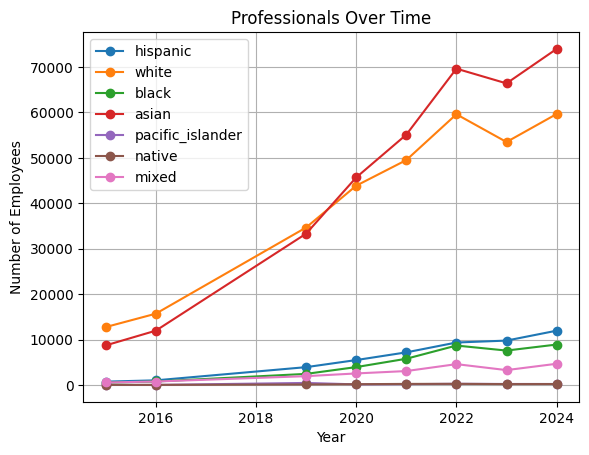

In [76]:
# Hm... it appears I did something in a much more complicated way oops.
# Ignore Gender, apply only the Total. Gender Analysis can be done later!!!!!!!!
# This organizes the table to include ONLY Professionals
df_professionals = df[df['job_category']=='Professionals'] 
df_professionals_totals = (
    df_professionals.groupby(['year','job_category'])
      .sum(numeric_only=True)
)
dfsomething = df_professionals_totals.groupby('year')[[
    'hispanic',
    'white',
    'black',
    'asian',
    'pacific_islander',
    'native',
    'mixed'
]].sum()
dfsomething.plot(kind='line', marker='o').plot(kind='line', marker='o')
plt.title('Professionals Over Time')
plt.ylabel('Number of Employees')
plt.xlabel('Year')
plt.grid(True)
plt.show()

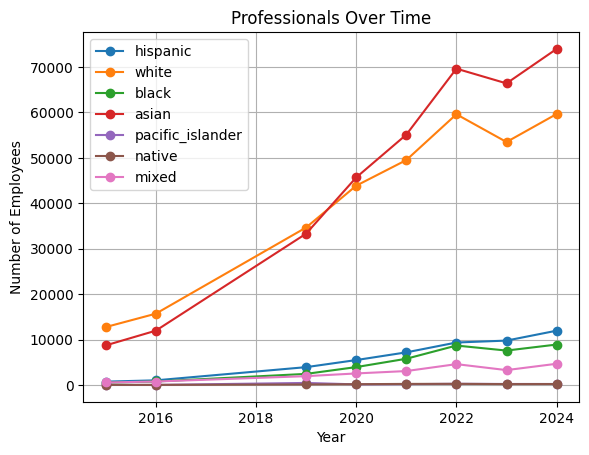

In [79]:
# Professional Diversity at Amazon = 
df_professionals_2 = df[df['job_Professionals'] == 1]
race_sum = df_professionals_2.groupby('year')[[
    'hispanic',
    'white',
    'black',
    'asian',
    'pacific_islander',
    'native',
    'mixed']].sum()
race_sum.plot(kind='line', marker='o')
plt.title('Professionals Over Time')
plt.ylabel('Number of Employees')
plt.xlabel('Year')
plt.grid(True)
plt.show()

In [81]:
# 1 Create a df that filters Professionals and sums up the totals
df_prof_growth = (
    df[df['job_category'] == 'Professionals']
      .groupby('year')[[
          'hispanic',
          'white',
          'black',
          'asian',
          'pacific_islander',
          'native',
          'mixed']] # year becomes index
      .sum(numeric_only=True) # sums the 
)
df_prof_growth.head()

,hispanic,white,black,asian,pacific_islander,native,mixed
year,,,,,,,
2015,766,12770,540,8739,43,46,576
2016,1052,15715,798,11977,44,53,794
2019,3953,34673,2470,33317,480,144,1970
2020,5513,43870,3967,45682,162,202,2569
2021,7207,49507,5800,55100,207,267,3094


In [82]:
#2 Find the growth rates
prof_growth = df_prof_growth.astype(int).pct_change() * 100 # also converts to Integer
prof_growth.head()

,hispanic,white,black,asian,pacific_islander,native,mixed
year,,,,,,,
2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016,37.336815,23.061864,47.777778,37.052294,2.325581,15.217391,37.847222
2019,275.760456,120.636335,209.523810,178.174835,990.909091,171.698113,148.110831
2020,39.463698,26.524962,60.607287,37.113185,-66.250000,40.277778,30.406091
2021,30.727372,12.849328,46.206201,20.616435,27.777778,32.178218,20.435967


<Figure size 640x480 with 0 Axes>

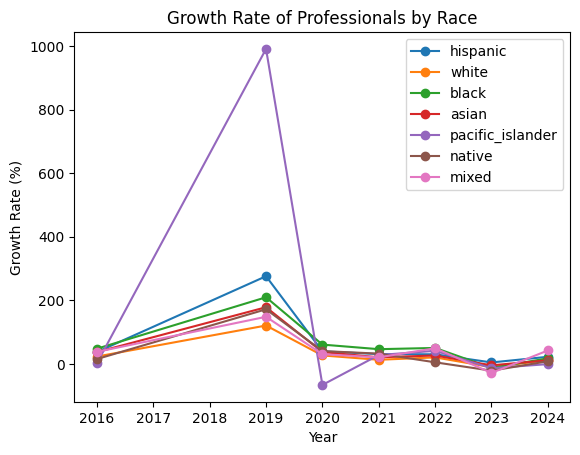

In [84]:
plt.figure()
# prof_growth.groupby('Year')[['Hispanic_or_Latino','White','Black_or_African_American','Asian','Native_Hawaiian_or_other_Pacific_Islander','American_Indian_or_Alaska_Native','Two_or_More_Races']].sum()
    # This part is redundat. 
prof_growth.plot(marker = 'o')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.title('Growth Rate of Professionals by Race')
plt.show()

In [36]:
# This is a guide to create a new df and organize them by values in a column.
# df_123 = (
#      df_1[df_2['Column_name'] == 'Value in Column']
#      .groupby('Categorical_Column')[['Column1', 'Column2', ..., 'ColumnX']]
#      .sum()

In [85]:
# 1 Create a df that filters Professionals and sums up the totals
df_service_growth = (
    df[df['job_category'] == 'Service Workers'] # makes sure we choose only Service Workers in the Job_Category column
      .groupby('year')[[
            'hispanic',
            'white',
            'black',
            'asian',
            'pacific_islander',
            'native',
            'mixed'
      ]] # year becomes index
      .sum(numeric_only=True) # sums the numeric values by the year
)
df_service_growth.head()

,hispanic,white,black,asian,pacific_islander,native,mixed
year,,,,,,,
2015,1,6,6,0,0,0,0
2016,5,15,11,1,0,0,1
2019,2706,2879,1860,533,54,56,200
2020,2474,2421,1542,527,51,53,189
2021,2735,2506,1805,623,51,58,220


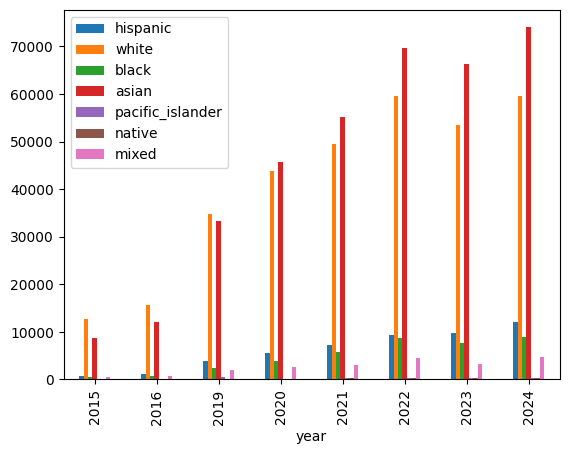

In [86]:
# ALTHOUGH I WANT TO DO GROWTH RATES, I CANT BECAUSE OF THE MISSING DATA 
df_prof_growth.plot( y=[
    'hispanic',
    'white',
    'black',
    'asian',
    'pacific_islander',
    'native',
    'mixed'], kind = 'bar')
plt.show()

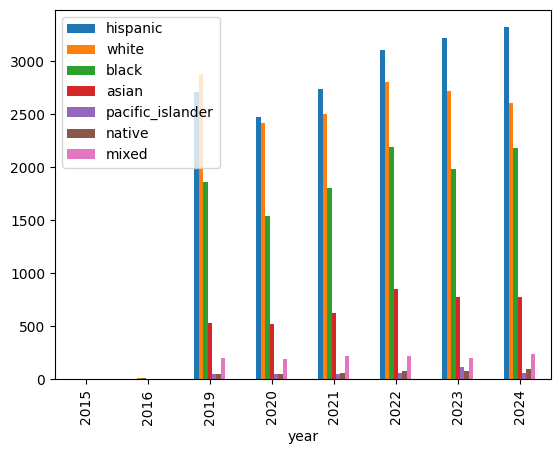

In [87]:
# ALTHOUGH I WANT TO DO GROWTH RATES, I CANT BECAUSE OF THE MISSING DATA 
df_service_growth.plot( y=[
     'hispanic',
    'white',
    'black',
    'asian',
    'pacific_islander',
    'native',
    'mixed'], kind = 'bar')
plt.show()

In [88]:
#2 Find the Growth Rates
serv_growth = df_service_growth.astype(int).pct_change()*100
serv_growth.head(10)

,hispanic,white,black,asian,pacific_islander,native,mixed
year,,,,,,,
2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016,400.000000,150.000000,83.333333,inf,NaN,NaN,inf
2019,54020.000000,19093.333333,16809.090909,5.320000e+04,inf,inf,1.990000e+04
2020,-8.573540,-15.908301,-17.096774,-1.125704e+00,-5.555556,-5.357143,-5.500000e+00
2021,10.549717,3.510946,17.055772,1.821632e+01,0.000000,9.433962,1.640212e+01
2022,13.601463,12.011173,21.551247,3.675762e+01,25.490196,39.655172,4.545455e-01
2023,3.669134,-2.992519,-9.525980,-8.450704e+00,85.937500,3.703704,-9.502262e+00
2024,2.980441,-4.333456,9.974811,-5.128205e-01,-47.899160,15.476190,1.800000e+01


<Figure size 640x480 with 0 Axes>

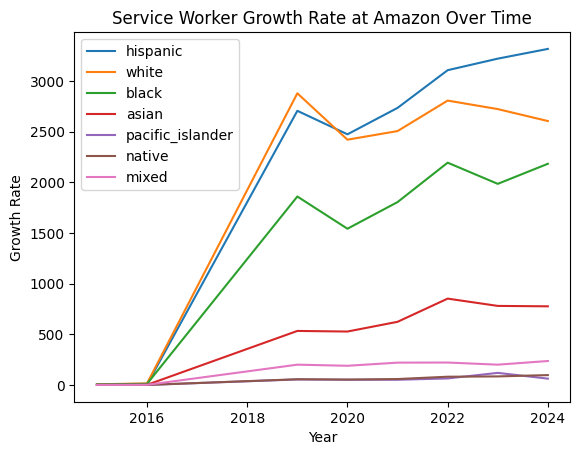

In [89]:
plt.figure()
#df_service_growth.groupby('Year')[['Hispanic_or_Latino','White','Black_or_African_American','Asian','Native_Hawaiian_or_other_Pacific_Islander','American_Indian_or_Alaska_Native','Two_or_More_Races']].sum()
    # This part is redundat. 
df_service_growth.plot()
plt.xlabel('Year')
plt.ylabel('Growth Rate')
plt.title('Service Worker Growth Rate at Amazon Over Time')
plt.show()

In [90]:
plt.figure()
serv_growth.groupby('Year')[['Hispanic_or_Latino','White','Black_or_African_American','Asian','Native_Hawaiian_or_other_Pacific_Islander','American_Indian_or_Alaska_Native','Two_or_More_Races']].sum()
    # This part is redundat. 
serv_growth.plot()
plt.xlabel('Year')
plt.ylabel('Growth Rate')
plt.title('Service Worker Growth Rate at Amazon Over Time')
plt.show()

KeyError: 'Year'

<Figure size 640x480 with 0 Axes>

In [91]:
df.head(20)

,year,job_category,hispanic,white,black,asian,pacific_islander,native,mixed,sex,...,job_Administrative_Support_Workers,job_Craft_Workers,job_Executive/Senior_Level_Officials_and_Managers,job_First/Mid-Level_Officials_and_Managers,job_Laborers_and_Helpers,job_Operatives,job_Professionals,job_Sales_Workers,job_Service_Workers,job_Technicians
0,2024,Executive/Senior Level Officials and Managers,149,1864,148,751,5,9,53,Male,...,0,0,1,0,0,0,0,0,0,0
1,2024,First/Mid-Level Officials and Managers,8222,28235,6769,10838,181,238,1691,Male,...,0,0,0,1,0,0,0,0,0,0
2,2024,Professionals,7675,41321,4688,49423,160,142,3092,Male,...,0,0,0,0,0,0,1,0,0,0
3,2024,Technicians,2806,5915,1704,1228,54,74,480,Male,...,0,0,0,0,0,0,0,0,0,1
4,2024,Sales Workers,12138,19247,9037,5578,209,444,1481,Male,...,0,0,0,0,0,0,0,1,0,0
5,2024,Administrative Support Workers,2994,5614,1680,987,73,141,499,Male,...,1,0,0,0,0,0,0,0,0,0
6,2024,Craft Workers,512,1430,224,117,9,24,93,Male,...,0,1,0,0,0,0,0,0,0,0
7,2024,Operatives,11551,15805,9977,3377,274,369,1384,Male,...,0,0,0,0,0,1,0,0,0,0
8,2024,Laborers and Helpers,97478,87379,120536,39622,2132,2818,9191,Male,...,0,0,0,0,1,0,0,0,0,0
9,2024,Service Workers,1920,1768,1352,469,41,64,136,Male,...,0,0,0,0,0,0,0,0,1,0
